# 🌾 Prédiction du Rendement Agricole — RAPIDS cuML + SHAP

**Pipeline GPU** | Dataset FAO FAOSTAT (Kaggle) | Google Colab T4  
Modèles : Random Forest · XGBoost · Régression Linéaire | Explicabilité : SHAP

> ⚠️ **Avant de démarrer** : *Modifier → Paramètres du notebook → Accélérateur matériel → GPU (T4)*

## 1. Vérification du GPU

In [15]:
# Vérification rapide : affiche le nom du GPU et la mémoire disponible
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader

Tesla T4, 15360 MiB


## 2. Installation RAPIDS + dépendances

*Cette étape prend ~10 minutes — ne pas interrompre.*

In [16]:
import subprocess, sys

# Installation RAPIDS via le script officiel rapidsai (détecte automatiquement la version CUDA)
try:
    import cuml
    print(f'cuML {cuml.__version__} déjà installé, on passe.')
except ImportError:
    subprocess.run(['git', 'clone', '--quiet',
                    'https://github.com/rapidsai/rapidsai-csp-utils.git'], check=True)
    subprocess.run([sys.executable, 'rapidsai-csp-utils/colab/pip-install.py'], check=True)

# Autres dépendances
!pip install -q kaggle xgboost>=2.0 shap>=0.45

cuML 26.02.000 déjà installé, on passe.


## 3. Imports

In [17]:
import warnings; warnings.filterwarnings('ignore')
import os, time
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.metrics          import mean_squared_error, r2_score
import xgboost as xgb
import shap

# ── Backend GPU (cuML) ou CPU (scikit-learn) selon disponibilité ──────────
USE_GPU = False
try:
    import cudf
    from cuml.ensemble     import RandomForestRegressor as RF
    from cuml.linear_model import LinearRegression     as LR
    USE_GPU = True
    print(f'✓ RAPIDS cuML {__import__("cuml").__version__} — mode GPU')
except ImportError:
    from sklearn.ensemble      import RandomForestRegressor as RF
    from sklearn.linear_model  import LinearRegression     as LR
    print('⚠ RAPIDS absent — fallback scikit-learn CPU')

print(f'XGBoost {xgb.__version__} | SHAP {shap.__version__}')

✓ RAPIDS cuML 26.02.000 — mode GPU
XGBoost 3.2.0 | SHAP 0.51.0


## 4. Chargement du dataset FAO FAOSTAT (Kaggle)

**Action requise :**  
1. Aller sur [kaggle.com → Settings → API → Create New Token](https://www.kaggle.com/settings)  
2. Télécharger le fichier `kaggle.json`  
3. Cliquer sur **« Choisir des fichiers »** dans la cellule suivante et sélectionner ce fichier


In [19]:
# CELLULE 4 : CHARGEMENT DU DATASET CROP YIELD PREDICTION (Kaggle)
import os, json
import pandas as pd
import numpy as np
from google.colab import files

# ── Étape 1 : Saisir votre username Kaggle ──────────────────────────────────
kaggle_username = input("Entrez votre nom d'utilisateur Kaggle : ")

# ── Étape 2 : Upload du fichier contenant la clé API ────────────────────────
print("\n🔑 Uploadez votre fichier contenant la clé API (kaggle.json ou fichier texte) :")
uploaded = files.upload()
fname = next(iter(uploaded))
content = uploaded[fname].decode('utf-8').strip()

# ── Étape 3 : Déterminer si c'est un JSON ou juste la clé ───────────────────
try:
    # Essayer de parser comme JSON (cas d'un vrai kaggle.json)
    data = json.loads(content)
    kaggle_key = data.get('key', content)
except json.JSONDecodeError:
    # Sinon, utiliser directement le contenu comme clé
    kaggle_key = content

# ── Étape 4 : Configuration de l'API Kaggle ────────────────────────────────
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": kaggle_username, "key": kaggle_key}, f)
!chmod 600 /root/.kaggle/kaggle.json
print(f"✓ Authentifié en tant que : {kaggle_username}")

# ── Étape 5 : Téléchargement du dataset ────────────────────────────────────
!kaggle datasets download patelris/crop-yield-prediction-dataset --unzip -q
print("✓ Dataset téléchargé et décompressé")

# ── Étape 6 : Chargement du CSV ────────────────────────────────────────────
df = pd.read_csv('yield_df.csv')

# ── Nettoyage et harmonisation ─────────────────────────────────────────────
df = df.rename(columns={
    'Area': 'country',
    'Item': 'crop',
    'Year': 'year',
    'hg/ha_yield': 'yield_hg_ha'
})
df = df.drop_duplicates()
df = df.dropna(subset=['yield_hg_ha', 'average_rain_fall_mm_per_year', 'avg_temp'])
df = df[df['yield_hg_ha'] > 0]

print(f"✓ Dataset final : {len(df):,} lignes")
print(f"  Pays : {df['country'].nunique()} | Cultures : {df['crop'].nunique()} | Années : {df['year'].min()}–{df['year'].max()}")
print("  Features disponibles :", [c for c in df.columns if c not in ['country', 'crop', 'year', 'yield_hg_ha']])
df.head()

Entrez votre nom d'utilisateur Kaggle : anass_brs

🔑 Uploadez votre fichier contenant la clé API (kaggle.json ou fichier texte) :


Saving access_token to access_token (1)
✓ Authentifié en tant que : anass_brs
Dataset URL: https://www.kaggle.com/datasets/patelris/crop-yield-prediction-dataset
License(s): world-bank
✓ Dataset téléchargé et décompressé
✓ Dataset final : 28,242 lignes
  Pays : 101 | Cultures : 10 | Années : 1990–2013
  Features disponibles : ['Unnamed: 0', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


,Unnamed: 0,country,crop,year,yield_hg_ha,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


## 5. Analyse exploratoire (EDA)

Valeurs manquantes :
     Unnamed: 0  country  crop  year  yield_hg_ha  \
NaN           0        0     0     0            0   

     average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp  
NaN                              0                  0         0  

Statistiques du rendement (hg/ha) :
count     28242.0
mean      77053.0
std       84957.0
min          50.0
25%       19919.0
50%       38295.0
75%      104677.0
max      501412.0
Name: yield_hg_ha, dtype: float64


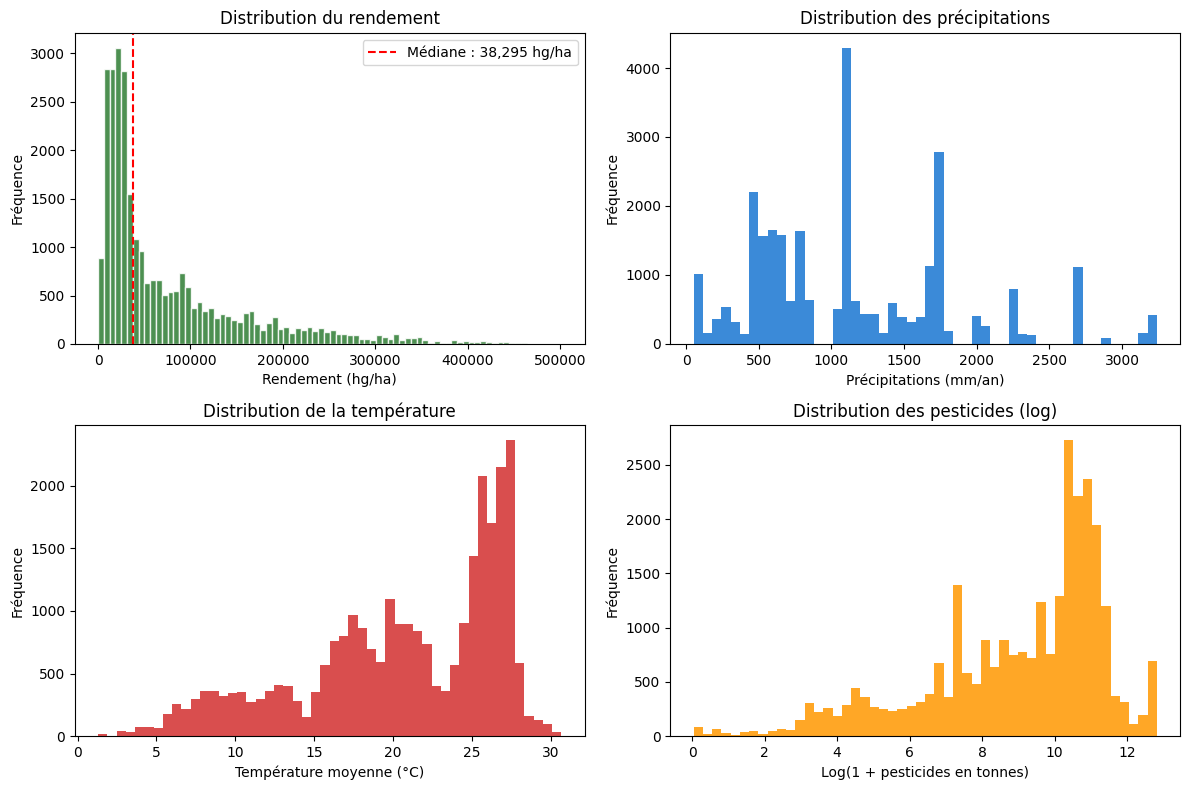

In [20]:
# CELLULE 5 : ANALYSE EXPLORATOIRE (EDA) enrichie
print('Valeurs manquantes :')
print(df.isnull().sum().to_frame('NaN').T)

print("\nStatistiques du rendement (hg/ha) :")
print(df['yield_hg_ha'].describe().round(0))

# Distribution du rendement
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
ax1 = axes[0,0]
ax1.hist(df['yield_hg_ha'], bins=80, color='#2E7D32', alpha=0.85, edgecolor='white')
ax1.axvline(df['yield_hg_ha'].median(), color='red', ls='--',
            label=f"Médiane : {df['yield_hg_ha'].median():,.0f} hg/ha")
ax1.set(xlabel='Rendement (hg/ha)', ylabel='Fréquence', title='Distribution du rendement')
ax1.legend()

# Distribution des précipitations
ax2 = axes[0,1]
ax2.hist(df['average_rain_fall_mm_per_year'], bins=50, color='#1976D2', alpha=0.85)
ax2.set(xlabel='Précipitations (mm/an)', ylabel='Fréquence', title='Distribution des précipitations')

# Température moyenne
ax3 = axes[1,0]
ax3.hist(df['avg_temp'], bins=50, color='#D32F2F', alpha=0.85)
ax3.set(xlabel='Température moyenne (°C)', ylabel='Fréquence', title='Distribution de la température')

# Pesticides (échelle log si nécessaire)
ax4 = axes[1,1]
ax4.hist(np.log1p(df['pesticides_tonnes']), bins=50, color='#FF9800', alpha=0.85)
ax4.set(xlabel='Log(1 + pesticides en tonnes)', ylabel='Fréquence', title='Distribution des pesticides (log)')

plt.tight_layout()
plt.show()

## 6. Prétraitement

In [21]:
# CELLULE 6 : PRÉTRAITEMENT AVEC FEATURES CLIMATIQUES
from sklearn.preprocessing import LabelEncoder

# Encodage des variables catégorielles
for col in ['country', 'crop']:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Feature engineering : année normalisée
df['year_trend'] = df['year'] - df['year'].min()

# Interaction culture × année (trend spécifique par culture)
df['crop_year'] = df['crop'] * df['year_trend']

# Liste des features : maintenant nous incluons les variables météo et pesticides
FEATURES = [
    'country', 'crop', 'year', 'year_trend', 'crop_year',
    'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'
]
TARGET = 'yield_hg_ha'

# Vérifier que toutes les colonnes existent
missing = [f for f in FEATURES if f not in df.columns]
if missing:
    raise KeyError(f"Colonnes manquantes : {missing}")

X = df[FEATURES].values.astype(np.float32)
y = df[TARGET].values.astype(np.float32)

print(f"X : {X.shape} | y : {y.shape}")
print("Features utilisées :", FEATURES)

X : (28242, 8) | y : (28242,)
Features utilisées : ['country', 'crop', 'year', 'year_trend', 'crop_year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


## 7. Split train/test + normalisation

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalisation utilisée uniquement pour la Régression Linéaire
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)

print(f'Train : {len(X_train):,} | Test : {len(X_test):,}')

Train : 22,593 | Test : 5,649


## 8. Transfert en mémoire GPU (cuDF)

In [23]:
if USE_GPU:
    # Transfert NumPy → cuDF : les données passent en VRAM
    Xtr   = cudf.DataFrame(X_train,    columns=FEATURES)
    Xte   = cudf.DataFrame(X_test,     columns=FEATURES)
    ytr   = cudf.Series(y_train)
    yte   = cudf.Series(y_test)
    Xtr_s = cudf.DataFrame(X_train_sc, columns=FEATURES)
    Xte_s = cudf.DataFrame(X_test_sc,  columns=FEATURES)
    print(f'✓ Données en VRAM — forme : {Xtr.shape}')
else:
    # Mode CPU : on réutilise directement les tableaux NumPy
    Xtr, Xte, ytr, yte   = X_train, X_test, y_train, y_test
    Xtr_s, Xte_s          = X_train_sc, X_test_sc
    print('Mode CPU — NumPy conservé')

✓ Données en VRAM — forme : (22593, 8)


## 9. Entraînement des modèles

In [24]:
def fit_eval(name, model, X_tr, X_te, y_tr, y_te):
    """Entraîne un modèle et retourne ses métriques RMSE / R²."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    # .to_numpy() gère les deux cas : cuDF Series ET NumPy array
    def to_np(x):
        return x.to_numpy() if hasattr(x, 'to_numpy') else np.asarray(x)

    p_tr = to_np(model.predict(X_tr)).ravel()
    p_te = to_np(model.predict(X_te)).ravel()
    y_tr_np = to_np(y_tr).ravel()
    y_te_np = to_np(y_te).ravel()

    m = {
        'model'      : model,
        'pred_test'  : p_te,
        'pred_train' : p_tr,
        'rmse_train' : np.sqrt(mean_squared_error(y_tr_np, p_tr)),
        'r2_train'   : r2_score(y_tr_np, p_tr),
        'rmse_test'  : np.sqrt(mean_squared_error(y_te_np, p_te)),
        'r2_test'    : r2_score(y_te_np, p_te),
        'time_s'     : elapsed,
    }
    print(f'{name:<22}  RMSE test {m["rmse_test"]:>10,.0f}  '
          f'R² test {m["r2_test"]:.4f}  {elapsed:.1f}s')
    return m


results = {}

# ── Random Forest (cuML GPU ou sklearn CPU) ───────────────────────────────
rf_kw = dict(n_estimators=100, max_depth=16, random_state=42)
if USE_GPU:
    rf_kw.update(n_bins=32, n_streams=4)
else:
    rf_kw['n_jobs'] = -1

results['Random Forest'] = fit_eval(
    'Random Forest', RF(**rf_kw), Xtr, Xte, ytr, yte
)

# ── XGBoost (GPU via device='cuda' si disponible) ─────────────────────────
results['XGBoost'] = fit_eval(
    'XGBoost',
    xgb.XGBRegressor(
        n_estimators=300, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        tree_method='hist',
        device='cuda' if USE_GPU else 'cpu',
        random_state=42, verbosity=0
    ),
    X_train, X_test, y_train, y_test    # XGBoost préfère NumPy directement
)

# ── Régression Linéaire (données normalisées) ─────────────────────────────
results['Lin. Regression'] = fit_eval(
    'Lin. Regression', LR(), Xtr_s, Xte_s, ytr, yte
)

Random Forest           RMSE test     10,127  R² test 0.9859  1.1s
XGBoost                 RMSE test     11,081  R² test 0.9831  1.1s
Lin. Regression         RMSE test     82,452  R² test 0.0628  0.4s


## 10. Tableau comparatif des performances


Modèle                   RMSE Train  R² Train    RMSE Test   R² Test   Temps
───────────────────────────────────────────────────────────────────────────
Random Forest ★               4,109    0.9977       10,127    0.9859    1.1s
XGBoost                       6,509    0.9941       11,081    0.9831    1.1s
Lin. Regression              82,297    0.0604       82,452    0.0628    0.4s

★ Meilleur modèle : Random Forest


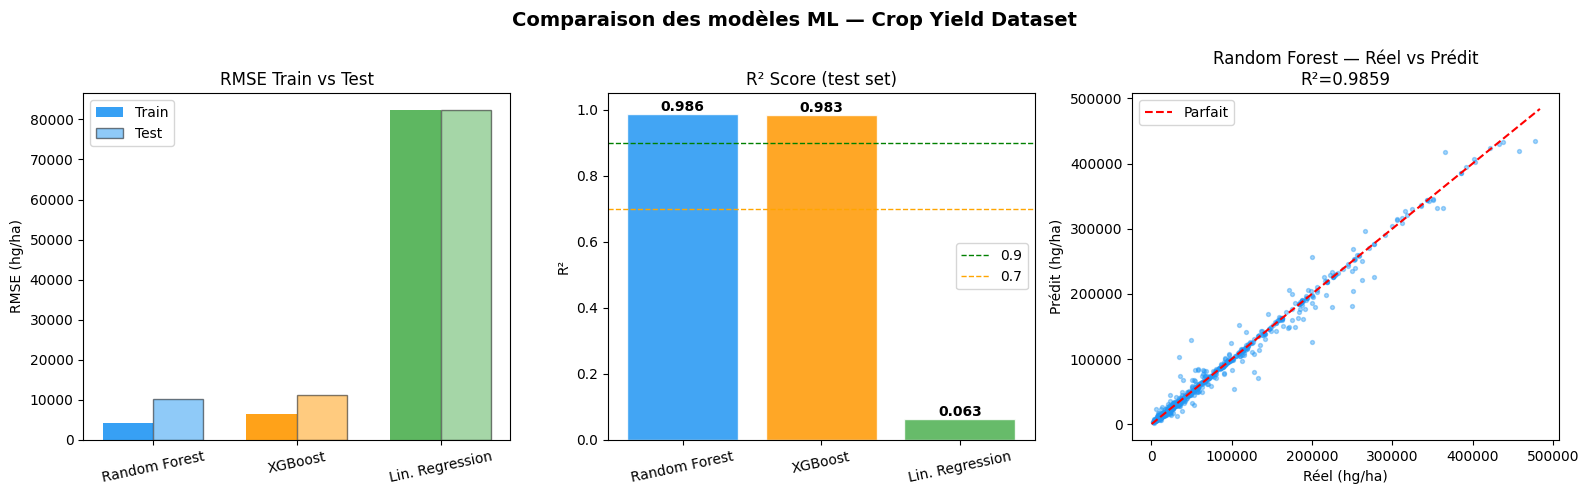

✓ model_comparison.png sauvegardé


In [25]:
# Tableau texte
print(f'\n{"Modèle":<22} {"RMSE Train":>12} {"R² Train":>9} '
      f'{"RMSE Test":>12} {"R² Test":>9} {"Temps":>7}')
print('─' * 75)

best = min(results, key=lambda k: results[k]['rmse_test'])
for name, m in results.items():
    star = ' ★' if name == best else ''
    print(f'{name+star:<22} {m["rmse_train"]:>12,.0f} {m["r2_train"]:>9.4f} '
          f'{m["rmse_test"]:>12,.0f} {m["r2_test"]:>9.4f} {m["time_s"]:>6.1f}s')

print(f'\n★ Meilleur modèle : {best}')

# ── Graphique comparatif (sauvegardé en PNG) ─────────────────────────────
model_names = list(results.keys())
colors      = ['#2196F3', '#FF9800', '#4CAF50']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparaison des modèles ML — Crop Yield Dataset', fontsize=14, fontweight='bold')

# RMSE train vs test
x = np.arange(len(model_names))
w = 0.35
axes[0].bar(x - w/2, [results[n]['rmse_train'] for n in model_names], w,
            label='Train', color=colors, alpha=0.9)
axes[0].bar(x + w/2, [results[n]['rmse_test']  for n in model_names], w,
            label='Test',  color=colors, alpha=0.5, edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, rotation=12)
axes[0].set_ylabel('RMSE (hg/ha)'); axes[0].set_title('RMSE Train vs Test')
axes[0].legend()

# R² test
bars = axes[1].bar(model_names, [results[n]['r2_test'] for n in model_names],
                   color=colors, alpha=0.85, edgecolor='white')
axes[1].axhline(0.9, color='green',  ls='--', lw=1, label='0.9')
axes[1].axhline(0.7, color='orange', ls='--', lw=1, label='0.7')
axes[1].set_ylim(0, 1.05); axes[1].set_ylabel('R²')
axes[1].set_title('R² Score (test set)'); axes[1].legend()
for b in bars:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                 f'{b.get_height():.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_xticklabels(model_names, rotation=12)

# Prédictions vs réalité (meilleur modèle)
y_true = y_test
y_pred = results[best]['pred_test']
idx_s  = np.random.choice(len(y_true), min(800, len(y_true)), replace=False)
color_best = colors[model_names.index(best)]
axes[2].scatter(y_true[idx_s], y_pred[idx_s], alpha=0.4, s=8, color=color_best)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
axes[2].plot(lims, lims, 'r--', lw=1.5, label='Parfait')
axes[2].set_xlabel('Réel (hg/ha)'); axes[2].set_ylabel('Prédit (hg/ha)')
axes[2].set_title(f'{best} — Réel vs Prédit\nR²={results[best]["r2_test"]:.4f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('✓ model_comparison.png sauvegardé')

## 11. Explicabilité SHAP (XGBoost — meilleur modèle)

SHAP calcule la contribution de chaque feature à chaque prédiction individuelle.

In [26]:
# Échantillon de 800 obs. du test set (compromis précision / vitesse)
rng       = np.random.default_rng(0)
idx_shap  = rng.choice(len(X_test), 800, replace=False)
X_shap    = X_test[idx_shap]

# TreeExplainer — compatible nativement avec XGBoost
explainer   = shap.TreeExplainer(results['XGBoost']['model'])
shap_values = explainer.shap_values(X_shap)   # shape : (800, n_features)

print(f'Valeurs SHAP calculées : {shap_values.shape}  (observations × features)')

Valeurs SHAP calculées : (800, 8)  (observations × features)


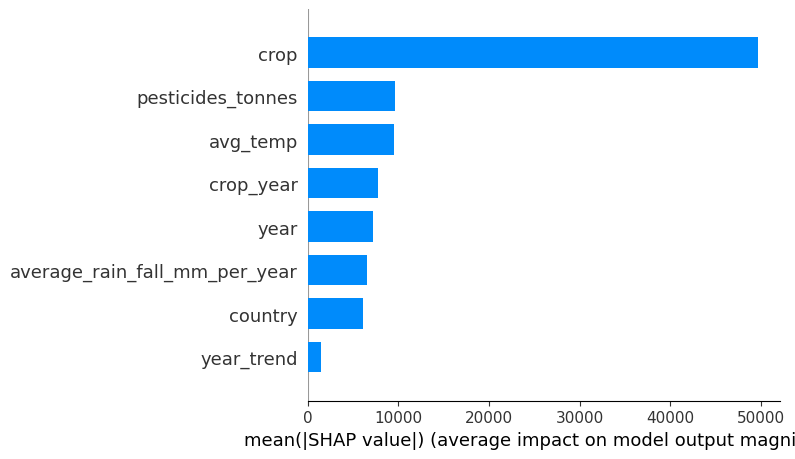

In [27]:
# Bar plot — importance globale : moyenne de |valeur SHAP| par feature
shap.summary_plot(shap_values, X_shap, feature_names=FEATURES, plot_type='bar')

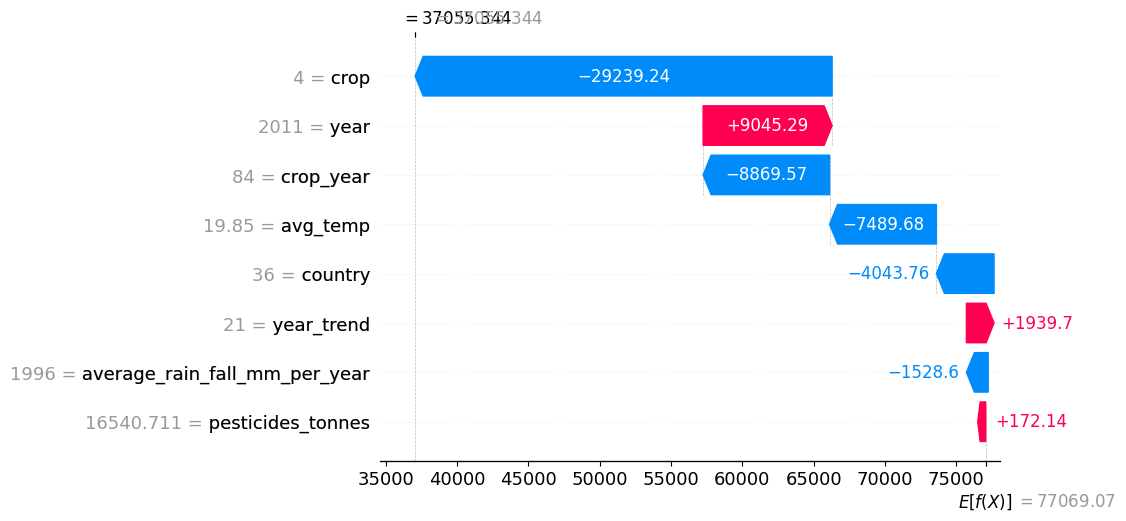

Réel   :     28,621 hg/ha
Prédit :     37,055 hg/ha


In [29]:
# Waterfall — décomposition d'une seule prédiction (la plus proche de la médiane)
xgb_preds = results['XGBoost']['pred_test'][idx_shap]
i_median  = int(np.argmin(np.abs(xgb_preds - np.median(xgb_preds))))

shap.plots.waterfall(
    shap.Explanation(
        values        = shap_values[i_median],
        base_values   = float(explainer.expected_value),
        data          = X_shap[i_median],
        feature_names = FEATURES
    )
)
print(f'Réel   : {y_test[idx_shap[i_median]]:>10,.0f} hg/ha')
print(f'Prédit : {xgb_preds[i_median]:>10,.0f} hg/ha')